In [4]:
# STEP 1 — Download Criteo Uplift Dataset from Hugging Face

import os
import requests
import pandas as pd

url = (
    "https://huggingface.co/datasets/"
    "criteo/criteo-uplift/resolve/main/"
    "criteo-research-uplift-v2.1.csv.gz"
)

output_path = "/content/criteo-uplift-v2.1.csv.gz"

print("Downloading Criteo dataset...")

response = requests.get(
    url,
    stream=True,
    timeout=120
)

response.raise_for_status()

total_size = int(
    response.headers.get(
        "content-length",
        0
    )
)

downloaded = 0

with open(
    output_path,
    "wb"
) as file:

    for chunk in response.iter_content(
        chunk_size=1024 * 1024
    ):

        if chunk:

            file.write(chunk)
            downloaded += len(chunk)

            if total_size:
                progress = (
                    downloaded /
                    total_size *
                    100
                )

                print(
                    f"\rProgress: {progress:.1f}%",
                    end=""
                )

print("\n")
print(
    f"Saved to: {output_path}"
)

print(
    f"File size: "
    f"{os.path.getsize(output_path) / (1024**2):.2f} MB"
)

Progress: 100.0%

Saved to: /content/criteo-uplift-v2.1.csv.gz
File size: 297.00 MB


In [8]:
# STEP 2 — Create a representative 500K sample
# from the entire Criteo Uplift dataset

import pandas as pd
import numpy as np

file_path = "/content/criteo-uplift-v2.1.csv.gz"

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

TARGET_SAMPLE = 500_000
CHUNK_SIZE = 200_000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

feature_columns = [
    "f0", "f1", "f2", "f3",
    "f4", "f5", "f6", "f7",
    "f8", "f9", "f10", "f11"
]

required_columns = (
    feature_columns
    + [
        "treatment",
        "conversion",
        "visit",
        "exposure"
    ]
)

# ---------------------------------------------------------
# PASS 1 — Count the full dataset by treatment/conversion
# ---------------------------------------------------------

print("PASS 1 — Counting treatment/conversion strata...")

strata_counts = {}

for chunk in pd.read_csv(
    file_path,
    compression="gzip",
    usecols=[
        "treatment",
        "conversion"
    ],
    chunksize=CHUNK_SIZE
):

    counts = (
        chunk
        .value_counts()
        .to_dict()
    )

    for key, value in counts.items():
        strata_counts[key] = (
            strata_counts.get(key, 0)
            + value
        )

print("\nFull dataset strata:")

for key, value in sorted(
    strata_counts.items()
):
    print(
        f"Treatment={key[0]}, "
        f"Conversion={key[1]}: "
        f"{value:,}"
    )

# ---------------------------------------------------------
# Calculate proportional sample size for every stratum
# ---------------------------------------------------------

total_rows = sum(
    strata_counts.values()
)

print(
    f"\nEstimated total rows: "
    f"{total_rows:,}"
)

sample_targets = {}

for key, count in strata_counts.items():

    target = int(
        round(
            TARGET_SAMPLE
            * count
            / total_rows
        )
    )

    sample_targets[key] = max(
        target,
        1
    )

# Correct rounding difference
difference = (
    TARGET_SAMPLE
    - sum(sample_targets.values())
)

if difference != 0:

    largest_stratum = max(
        sample_targets,
        key=sample_targets.get
    )

    sample_targets[
        largest_stratum
    ] += difference

print("\nTarget sample per stratum:")

for key, value in sorted(
    sample_targets.items()
):
    print(
        f"Treatment={key[0]}, "
        f"Conversion={key[1]}: "
        f"{value:,}"
    )

# ---------------------------------------------------------
# PASS 2 — Sample proportionally from each chunk
# ---------------------------------------------------------

print(
    "\nPASS 2 — Sampling from entire dataset..."
)

sampled_chunks = []

for chunk_number, chunk in enumerate(
    pd.read_csv(
        file_path,
        compression="gzip",
        usecols=required_columns,
        chunksize=CHUNK_SIZE
    ),
    start=1
):

    chunk_samples = []

    for key, target_total in sample_targets.items():

        t_value, c_value = key

        stratum = chunk[
            (chunk["treatment"] == t_value)
            &
            (chunk["conversion"] == c_value)
        ]

        if len(stratum) == 0:
            continue

        # Estimate this chunk's fair share
        # from the full stratum
        full_stratum_count = (
            strata_counts[key]
        )

        chunk_target = int(
            round(
                target_total
                * len(stratum)
                / full_stratum_count
            )
        )

        chunk_target = min(
            chunk_target,
            len(stratum)
        )

        if chunk_target > 0:

            sampled = stratum.sample(
                n=chunk_target,
                random_state=(
                    RANDOM_STATE
                    + chunk_number
                    + int(t_value) * 100
                    + int(c_value) * 10
                )
            )

            chunk_samples.append(
                sampled
            )

    if chunk_samples:
        sampled_chunks.append(
            pd.concat(
                chunk_samples,
                ignore_index=True
            )
        )

    if chunk_number % 10 == 0:
        print(
            f"Processed chunk {chunk_number}..."
        )

# ---------------------------------------------------------
# Combine samples
# ---------------------------------------------------------

df = pd.concat(
    sampled_chunks,
    ignore_index=True
)

# Shuffle final sample
df = (
    df
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

# Remove accidental duplicates
before_duplicates = len(df)

df = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)

after_duplicates = len(df)

# ---------------------------------------------------------
# Final report
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL SAMPLE")
print("=" * 60)

print(
    f"Shape: {df.shape}"
)

print(
    f"Rows before duplicate removal: "
    f"{before_duplicates:,}"
)

print(
    f"Rows after duplicate removal: "
    f"{after_duplicates:,}"
)

print("\nTreatment distribution:")
print(
    df["treatment"]
    .value_counts()
    .sort_index()
)

print("\nTreatment percentage:")
print(
    (
        df["treatment"]
        .value_counts(
            normalize=True
        )
        .sort_index()
        * 100
    ).round(4)
)

print("\nConversion distribution:")
print(
    df["conversion"]
    .value_counts()
    .sort_index()
)

print("\nTreatment × Conversion:")
print(
    pd.crosstab(
        df["treatment"],
        df["conversion"]
    )
)

print("\nTreatment × Conversion percentage:")
print(
    (
        pd.crosstab(
            df["treatment"],
            df["conversion"],
            normalize="index"
        )
        * 100
    ).round(4)
)

PASS 1 — Counting treatment/conversion strata...

Full dataset strata:
Treatment=0, Conversion=0: 2,092,874
Treatment=0, Conversion=1: 4,063
Treatment=1, Conversion=0: 11,845,944
Treatment=1, Conversion=1: 36,711

Estimated total rows: 13,979,592

Target sample per stratum:
Treatment=0, Conversion=0: 74,855
Treatment=0, Conversion=1: 145
Treatment=1, Conversion=0: 423,687
Treatment=1, Conversion=1: 1,313

PASS 2 — Sampling from entire dataset...
Processed chunk 10...
Processed chunk 20...
Processed chunk 30...
Processed chunk 40...
Processed chunk 50...
Processed chunk 60...
Processed chunk 70...

FINAL SAMPLE
Shape: (498002, 16)
Rows before duplicate removal: 499,998
Rows after duplicate removal: 498,002

Treatment distribution:
treatment
0     74940
1    423062
Name: count, dtype: int64

Treatment percentage:
treatment
0    15.0481
1    84.9519
Name: proportion, dtype: float64

Conversion distribution:
conversion
0    496546
1      1456
Name: count, dtype: int64

Treatment × Conversi

In [9]:
# STEP 3 — Campaign effectiveness and Average Treatment Effect

import pandas as pd
import numpy as np

# Conversion statistics by treatment group
treatment_stats = (
    df.groupby("treatment")["conversion"]
    .agg(
        customers="count",
        conversions="sum",
        conversion_rate="mean"
    )
    .reset_index()
)

treatment_stats["conversion_rate_pct"] = (
    treatment_stats["conversion_rate"] * 100
)

print("Treatment Performance")
print("=" * 60)
display(treatment_stats)

# Extract conversion rates
control_rate = (
    df.loc[
        df["treatment"] == 0,
        "conversion"
    ].mean()
)

treatment_rate = (
    df.loc[
        df["treatment"] == 1,
        "conversion"
    ].mean()
)

# Average Treatment Effect
ate = treatment_rate - control_rate

# Relative lift
relative_lift = (
    ate / control_rate
    if control_rate > 0
    else np.nan
)

print("\nCampaign Effect")
print("=" * 60)

print(
    f"Control Conversion Rate   : "
    f"{control_rate:.6f} "
    f"({control_rate * 100:.4f}%)"
)

print(
    f"Treatment Conversion Rate : "
    f"{treatment_rate:.6f} "
    f"({treatment_rate * 100:.4f}%)"
)

print(
    f"Average Treatment Effect  : "
    f"{ate:.6f}"
)

print(
    f"Absolute Lift             : "
    f"{ate * 100:.4f} percentage points"
)

print(
    f"Relative Lift             : "
    f"{relative_lift * 100:.2f}%"
)

# Crosstab for clearer interpretation
print("\nTreatment × Conversion")
print("=" * 60)

conversion_table = pd.crosstab(
    df["treatment"],
    df["conversion"]
)

display(conversion_table)

# Interpretation
if ate > 0:
    print(
        "\nResult: Treatment shows a positive "
        "average effect on conversion."
    )
elif ate < 0:
    print(
        "\nResult: Treatment shows a negative "
        "average effect on conversion."
    )
else:
    print(
        "\nResult: No average treatment effect "
        "was observed."
    )

Treatment Performance


,treatment,customers,conversions,conversion_rate,conversion_rate_pct
0,0,74940,145,0.001935,0.193488
1,1,423062,1311,0.003099,0.309884



Campaign Effect
Control Conversion Rate   : 0.001935 (0.1935%)
Treatment Conversion Rate : 0.003099 (0.3099%)
Average Treatment Effect  : 0.001164
Absolute Lift             : 0.1164 percentage points
Relative Lift             : 60.16%

Treatment × Conversion


conversion,0,1
treatment,,
0,74795,145
1,421751,1311



Result: Treatment shows a positive average effect on conversion.


In [11]:
# ============================================================
# STEP 4 — S-LEARNER UPLIFT MODELING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklift.models import SoloModel

# ------------------------------------------------------------
# 1. Define features, treatment, and target
# ------------------------------------------------------------

feature_columns = [
    f"f{i}"
    for i in range(12)
]

X = df[feature_columns].copy()

treatment = df["treatment"].copy()

y = df["conversion"].copy()

print("=" * 60)
print("DATA PREPARATION")
print("=" * 60)

print("Feature shape :", X.shape)
print("Treatment     :", treatment.shape)
print("Target        :", y.shape)

# ------------------------------------------------------------
# 2. Create stratification variable
# ------------------------------------------------------------

strata = (
    treatment.astype(str)
    + "_"
    + y.astype(str)
)

# ------------------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test, t_train, t_test = (
    train_test_split(
        X,
        y,
        treatment,
        test_size=0.20,
        random_state=42,
        stratify=strata
    )
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(
    f"Training samples : {len(X_train):,}"
)

print(
    f"Testing samples  : {len(X_test):,}"
)

print("\nTraining treatment distribution:")
print(
    t_train.value_counts()
)

print("\nTesting treatment distribution:")
print(
    t_test.value_counts()
)

# ------------------------------------------------------------
# 4. S-Learner base model
# ------------------------------------------------------------

base_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 5. Build S-Learner
# ------------------------------------------------------------

s_learner = SoloModel(
    base_model
)

# ------------------------------------------------------------
# 6. Train S-Learner
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING S-LEARNER")
print("=" * 60)

s_learner.fit(
    X_train,
    y_train,
    t_train
)

print("S-Learner training completed.")

# ------------------------------------------------------------
# 7. Predict individual uplift
# ------------------------------------------------------------

uplift_s = s_learner.predict(
    X_test
)

# ------------------------------------------------------------
# 8. Create result dataframe
# ------------------------------------------------------------

s_uplift_results = X_test.copy()

s_uplift_results["Treatment"] = (
    t_test.values
)

s_uplift_results["Actual"] = (
    y_test.values
)

s_uplift_results["Uplift"] = (
    uplift_s
)

# ------------------------------------------------------------
# 9. Uplift summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("S-LEARNER UPLIFT RESULTS")
print("=" * 60)

print(
    f"Test customers : {len(uplift_s):,}"
)

print(
    f"Minimum uplift : {uplift_s.min():.6f}"
)

print(
    f"Maximum uplift : {uplift_s.max():.6f}"
)

print(
    f"Mean uplift    : {uplift_s.mean():.6f}"
)

print(
    f"Median uplift  : {np.median(uplift_s):.6f}"
)

# ------------------------------------------------------------
# 10. Positive / Negative uplift
# ------------------------------------------------------------

positive_count = (
    (uplift_s > 0).sum()
)

negative_count = (
    (uplift_s < 0).sum()
)

neutral_count = (
    (uplift_s == 0).sum()
)

print("\nUplift distribution:")
print(
    f"Positive uplift : {positive_count:,}"
)

print(
    f"Negative uplift : {negative_count:,}"
)

print(
    f"Zero uplift     : {neutral_count:,}"
)

# ------------------------------------------------------------
# 11. Top 20 customers by predicted uplift
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TOP 20 CUSTOMERS BY PREDICTED UPLIFT")
print("=" * 60)

display(
    s_uplift_results
    .sort_values(
        "Uplift",
        ascending=False
    )
    .head(20)
)

DATA PREPARATION
Feature shape : (498002, 12)
Treatment     : (498002,)
Target        : (498002,)

TRAIN / TEST SPLIT
Training samples : 398,401
Testing samples  : 99,601

Training treatment distribution:
treatment
1    338449
0     59952
Name: count, dtype: int64

Testing treatment distribution:
treatment
1    84613
0    14988
Name: count, dtype: int64

TRAINING S-LEARNER
S-Learner training completed.

S-LEARNER UPLIFT RESULTS
Test customers : 99,601
Minimum uplift : -0.003838
Maximum uplift : 0.021179
Mean uplift    : 0.000078
Median uplift  : 0.000020

Uplift distribution:
Positive uplift : 84,676
Negative uplift : 14,925
Zero uplift     : 0

TOP 20 CUSTOMERS BY PREDICTED UPLIFT


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,Treatment,Actual,Uplift
450193,12.813005,12.178963,8.298022,-4.022942,16.532873,-3.506396,-22.866028,6.508036,3.711237,50.137758,5.417894,-0.703380,1,0,0.021179
127129,15.609061,10.059654,8.227107,-0.346278,13.875414,4.115453,-10.006574,4.833815,3.771226,47.596788,5.318203,-0.583534,1,1,0.018737
24129,12.818817,11.739167,8.233877,-1.950238,13.253813,0.709409,-15.202774,5.810612,3.764802,49.665281,5.327689,-0.506038,0,0,0.017697
371352,12.701951,10.679513,8.275099,-1.829275,15.283397,1.624218,-22.680752,5.739395,3.736351,42.018683,5.390587,-0.436029,0,0,0.017518
315818,17.295264,10.059654,8.224746,-1.372812,15.402626,4.115453,-14.005516,4.833815,3.771371,38.273025,5.316079,-0.473542,1,0,0.016517
246279,12.753790,11.974826,8.287404,0.201621,18.155432,0.709409,-9.238756,4.907882,3.711972,61.100610,5.405555,-1.206014,1,1,0.016353
332175,12.935820,10.679513,8.215312,-0.277014,14.122101,3.013064,-9.864621,5.640746,3.794457,45.907031,5.305773,-0.674717,0,0,0.016101
35444,12.625536,10.679513,8.214612,-2.007956,15.220767,1.128518,-18.952194,7.047581,3.729011,53.028702,5.327402,-0.729019,1,1,0.015894
250871,12.668579,10.679513,8.214447,-3.425053,15.088753,3.013064,-16.316465,4.859503,3.775665,47.596788,5.302579,-0.763031,0,0,0.015858
28402,12.730890,11.460441,8.240409,-3.356290,14.439578,-1.538186,-20.237259,5.353890,3.737981,46.714867,5.385348,-0.583534,0,0,0.015852


In [12]:
# ============================================================
# STEP 5 — T-LEARNER / TWO-MODEL UPLIFT MODEL
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklift.models import TwoModels

# ------------------------------------------------------------
# 1. Prepare training and testing data
# ------------------------------------------------------------

X_train_t = X_train.copy()
X_test_t = X_test.copy()

y_train_t = y_train.copy()
y_test_t = y_test.copy()

t_train_t = t_train.copy()
t_test_t = t_test.copy()

print("=" * 60)
print("T-LEARNER DATA PREPARATION")
print("=" * 60)

print(
    f"Training samples : {len(X_train_t):,}"
)

print(
    f"Testing samples  : {len(X_test_t):,}"
)

print("\nTraining treatment distribution:")
print(
    t_train_t.value_counts()
)

print("\nTesting treatment distribution:")
print(
    t_test_t.value_counts()
)

# ------------------------------------------------------------
# 2. Create separate base models
# ------------------------------------------------------------

treated_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

control_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 3. Build Two-Model / T-Learner
# ------------------------------------------------------------

t_learner = TwoModels(
    estimator_trmnt=treated_model,
    estimator_ctrl=control_model
)

# ------------------------------------------------------------
# 4. Train
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING T-LEARNER")
print("=" * 60)

t_learner.fit(
    X_train_t,
    y_train_t,
    t_train_t
)

print(
    "T-Learner training completed."
)

# ------------------------------------------------------------
# 5. Predict individual treatment effect
# ------------------------------------------------------------

uplift_t = t_learner.predict(
    X_test_t
)

# ------------------------------------------------------------
# 6. Create result dataframe
# ------------------------------------------------------------

t_uplift_results = X_test_t.copy()

t_uplift_results["Treatment"] = (
    t_test_t.values
)

t_uplift_results["Actual"] = (
    y_test_t.values
)

t_uplift_results["Uplift"] = (
    uplift_t
)

# ------------------------------------------------------------
# 7. Basic uplift statistics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("T-LEARNER UPLIFT RESULTS")
print("=" * 60)

print(
    f"Test customers : "
    f"{len(uplift_t):,}"
)

print(
    f"Minimum uplift : "
    f"{uplift_t.min():.6f}"
)

print(
    f"Maximum uplift : "
    f"{uplift_t.max():.6f}"
)

print(
    f"Mean uplift    : "
    f"{uplift_t.mean():.6f}"
)

print(
    f"Median uplift  : "
    f"{np.median(uplift_t):.6f}"
)

# ------------------------------------------------------------
# 8. Positive / Negative uplift
# ------------------------------------------------------------

positive_count_t = (
    (uplift_t > 0).sum()
)

negative_count_t = (
    (uplift_t < 0).sum()
)

zero_count_t = (
    (uplift_t == 0).sum()
)

print("\nUplift distribution:")

print(
    f"Positive uplift : "
    f"{positive_count_t:,}"
)

print(
    f"Negative uplift : "
    f"{negative_count_t:,}"
)

print(
    f"Zero uplift     : "
    f"{zero_count_t:,}"
)

# ------------------------------------------------------------
# 9. Top 20 customers by uplift
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TOP 20 CUSTOMERS BY T-LEARNER UPLIFT")
print("=" * 60)

display(
    t_uplift_results
    .sort_values(
        "Uplift",
        ascending=False
    )
    .head(20)
)

T-LEARNER DATA PREPARATION
Training samples : 398,401
Testing samples  : 99,601

Training treatment distribution:
treatment
1    338449
0     59952
Name: count, dtype: int64

Testing treatment distribution:
treatment
1    84613
0    14988
Name: count, dtype: int64

TRAINING T-LEARNER
T-Learner training completed.

T-LEARNER UPLIFT RESULTS
Test customers : 99,601
Minimum uplift : -0.100392
Maximum uplift : 0.373543
Mean uplift    : 0.000915
Median uplift  : 0.000103

Uplift distribution:
Positive uplift : 85,530
Negative uplift : 14,071
Zero uplift     : 0

TOP 20 CUSTOMERS BY T-LEARNER UPLIFT


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,Treatment,Actual,Uplift
246279,12.753790,11.974826,8.287404,0.201621,18.155432,0.709409,-9.238756,4.907882,3.711972,61.100610,5.405555,-1.206014,1,1,0.373543
250871,12.668579,10.679513,8.214447,-3.425053,15.088753,3.013064,-16.316465,4.859503,3.775665,47.596788,5.302579,-0.763031,0,0,0.361790
22458,12.621978,10.679513,8.215508,-2.197214,15.283397,2.230907,-14.386627,8.027677,3.781388,46.757291,5.301952,-0.792867,1,1,0.354614
332175,12.935820,10.679513,8.215312,-0.277014,14.122101,3.013064,-9.864621,5.640746,3.794457,45.907031,5.305773,-0.674717,0,0,0.347834
260248,14.396483,10.059654,8.215162,-1.700105,16.436464,3.013064,-15.969277,11.838134,3.680749,59.000336,5.306402,-0.752213,1,1,0.345656
154573,13.108499,10.059654,8.234532,-2.751536,18.921756,4.115453,-20.539538,4.833815,3.679216,54.227260,5.415641,-0.819440,1,1,0.332049
170493,13.596562,10.059654,8.214413,-4.943806,17.207387,-0.973651,-22.620658,8.981224,3.731713,52.135331,5.300911,-0.936944,1,1,0.318677
450193,12.813005,12.178963,8.298022,-4.022942,16.532873,-3.506396,-22.866028,6.508036,3.711237,50.137758,5.417894,-0.703380,1,0,0.313947
349448,12.616365,10.059654,8.221249,4.679882,17.250352,4.115453,0.294443,4.833815,3.707539,61.936709,5.310728,-1.086791,1,1,0.310278
219324,13.714742,11.119309,8.299133,-1.525255,15.670836,1.128518,-19.717495,7.504483,3.707509,54.085534,5.419270,-0.659011,1,0,0.309798


In [13]:
# ============================================================
# STEP 6 — EVALUATE S-LEARNER vs T-LEARNER
# ============================================================

import pandas as pd
import numpy as np

from sklift.metrics import (
    qini_auc_score,
    uplift_auc_score,
    uplift_at_k
)

# ------------------------------------------------------------
# 1. Evaluate Qini AUC
# ------------------------------------------------------------

qini_s = qini_auc_score(
    y_test,
    uplift_s,
    t_test
)

qini_t = qini_auc_score(
    y_test,
    uplift_t,
    t_test
)

# ------------------------------------------------------------
# 2. Evaluate AUUC
# ------------------------------------------------------------

auuc_s = uplift_auc_score(
    y_test,
    uplift_s,
    t_test
)

auuc_t = uplift_auc_score(
    y_test,
    uplift_t,
    t_test
)

# ------------------------------------------------------------
# 3. Evaluate Uplift at different targeting levels
# ------------------------------------------------------------

targeting_levels = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

evaluation_rows = []

for k in targeting_levels:

    uplift_s_k = uplift_at_k(
        y_test,
        uplift_s,
        t_test,
        strategy="overall",
        k=k
    )

    uplift_t_k = uplift_at_k(
        y_test,
        uplift_t,
        t_test,
        strategy="overall",
        k=k
    )

    evaluation_rows.append({
        "Targeting": f"{int(k * 100)}%",
        "S-Learner": uplift_s_k,
        "T-Learner": uplift_t_k
    })

targeting_evaluation = pd.DataFrame(
    evaluation_rows
)

# ------------------------------------------------------------
# 4. Create overall comparison table
# ------------------------------------------------------------

uplift_model_comparison = pd.DataFrame({
    "Model": [
        "S-Learner",
        "T-Learner"
    ],
    "Qini_AUC": [
        qini_s,
        qini_t
    ],
    "AUUC": [
        auuc_s,
        auuc_t
    ]
})

# ------------------------------------------------------------
# 5. Print results
# ------------------------------------------------------------

print("=" * 60)
print("UPLIFT MODEL EVALUATION")
print("=" * 60)

print("\nQini AUC / AUUC:")
display(
    uplift_model_comparison
)

print("\nUplift at Targeting Levels:")
display(
    targeting_evaluation
)

# ------------------------------------------------------------
# 6. Determine best model
# ------------------------------------------------------------

best_model_idx = (
    uplift_model_comparison[
        "Qini_AUC"
    ].idxmax()
)

best_uplift_model = (
    uplift_model_comparison
    .loc[
        best_model_idx,
        "Model"
    ]
)

print(
    "\nBest model based on Qini AUC:",
    best_uplift_model
)

UPLIFT MODEL EVALUATION

Qini AUC / AUUC:


,Model,Qini_AUC,AUUC
0,S-Learner,0.150472,0.004840
1,T-Learner,0.140386,0.004524



Uplift at Targeting Levels:


,Targeting,S-Learner,T-Learner
0,10%,0.007219,0.007564
1,20%,0.004157,0.004390
2,30%,0.003145,0.003134
3,40%,0.002428,0.002388
4,50%,0.001993,0.001945



Best model based on Qini AUC: S-Learner


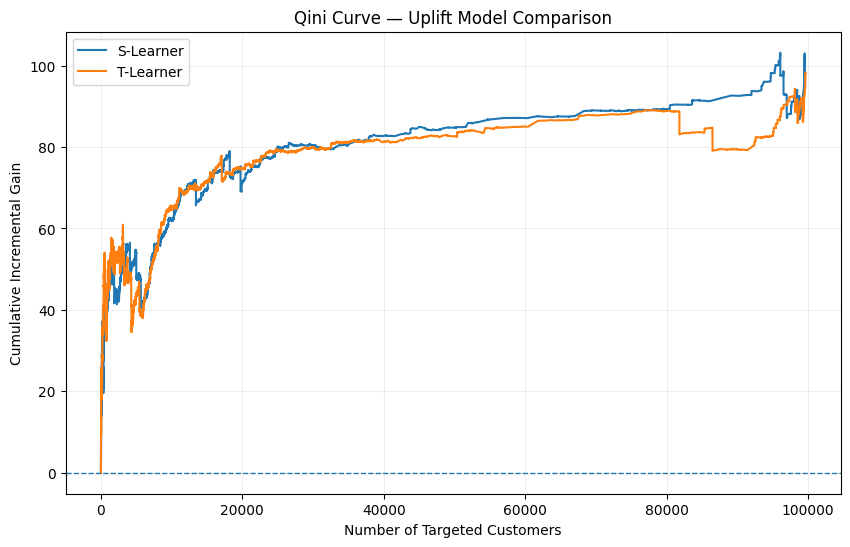

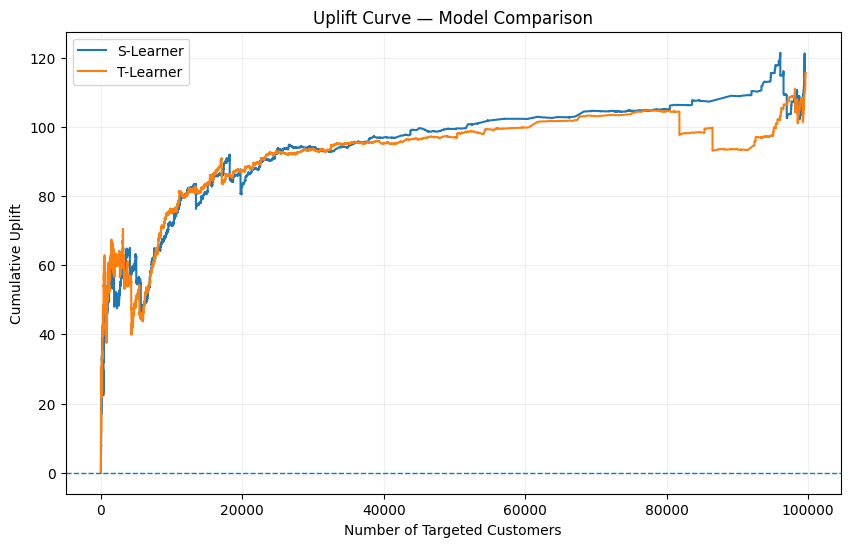

In [14]:
# ============================================================
# STEP 7 — QINI CURVE & UPLIFT CURVE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklift.metrics import (
    qini_curve,
    uplift_curve
)

# ------------------------------------------------------------
# 1. Calculate Qini curves
# ------------------------------------------------------------

x_s_qini, y_s_qini = qini_curve(
    y_test,
    uplift_s,
    t_test
)

x_t_qini, y_t_qini = qini_curve(
    y_test,
    uplift_t,
    t_test
)

# ------------------------------------------------------------
# 2. Plot Qini Curve
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    x_s_qini,
    y_s_qini,
    label="S-Learner"
)

plt.plot(
    x_t_qini,
    y_t_qini,
    label="T-Learner"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Qini Curve — Uplift Model Comparison"
)

plt.xlabel(
    "Number of Targeted Customers"
)

plt.ylabel(
    "Cumulative Incremental Gain"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 3. Calculate Uplift Curves
# ------------------------------------------------------------

x_s_uplift, y_s_uplift = uplift_curve(
    y_test,
    uplift_s,
    t_test
)

x_t_uplift, y_t_uplift = uplift_curve(
    y_test,
    uplift_t,
    t_test
)

# ------------------------------------------------------------
# 4. Plot Uplift Curve
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    x_s_uplift,
    y_s_uplift,
    label="S-Learner"
)

plt.plot(
    x_t_uplift,
    y_t_uplift,
    label="T-Learner"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Uplift Curve — Model Comparison"
)

plt.xlabel(
    "Number of Targeted Customers"
)

plt.ylabel(
    "Cumulative Uplift"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

CUSTOMER UPLIFT SEGMENTS


,customers,avg_uplift,min_uplift,max_uplift
Segment,,,,
High Uplift,254,0.008470,0.005008,0.021179
Positive Uplift,1084,0.002208,0.001000,0.004984
Neutral,98113,0.000035,-0.000998,0.000999
Negative Uplift,150,-0.001594,-0.003838,-0.001003



Segment percentage:


,proportion
Segment,
Neutral,98.51
Positive Uplift,1.09
High Uplift,0.26
Negative Uplift,0.15


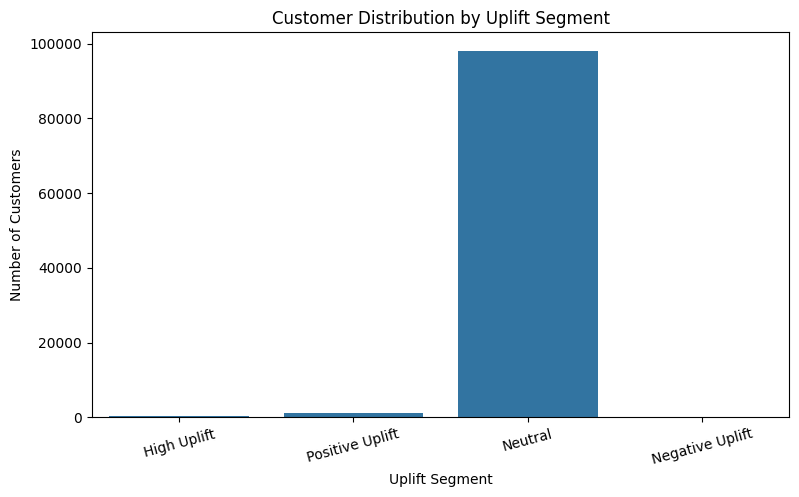

In [15]:
# ============================================================
# STEP 8 — CUSTOMER UPLIFT SEGMENTATION
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Create customer-level uplift dataframe
# ------------------------------------------------------------

final_uplift_df = X_test.copy()

final_uplift_df["Treatment"] = (
    t_test.values
)

final_uplift_df["Actual"] = (
    y_test.values
)

final_uplift_df["Uplift"] = (
    uplift_s
)

# ------------------------------------------------------------
# 2. Define uplift segments
# ------------------------------------------------------------

def classify_uplift(value):

    if value >= 0.005:
        return "High Uplift"

    elif value >= 0.001:
        return "Positive Uplift"

    elif value <= -0.001:
        return "Negative Uplift"

    else:
        return "Neutral"

final_uplift_df["Segment"] = (
    final_uplift_df["Uplift"]
    .apply(classify_uplift)
)

# ------------------------------------------------------------
# 3. Segment summary
# ------------------------------------------------------------

segment_summary = (
    final_uplift_df
    .groupby("Segment")
    .agg(
        customers=(
            "Segment",
            "count"
        ),
        avg_uplift=(
            "Uplift",
            "mean"
        ),
        min_uplift=(
            "Uplift",
            "min"
        ),
        max_uplift=(
            "Uplift",
            "max"
        )
    )
    .sort_values(
        "avg_uplift",
        ascending=False
    )
)

print("=" * 60)
print("CUSTOMER UPLIFT SEGMENTS")
print("=" * 60)

display(
    segment_summary
)

# ------------------------------------------------------------
# 4. Segment percentage
# ------------------------------------------------------------

segment_percentage = (
    final_uplift_df["Segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(
    "\nSegment percentage:"
)

display(
    segment_percentage
)

# ------------------------------------------------------------
# 5. Segment visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    x=segment_summary.index,
    y=segment_summary["customers"]
)

plt.title(
    "Customer Distribution by Uplift Segment"
)

plt.xlabel(
    "Uplift Segment"
)

plt.ylabel(
    "Number of Customers"
)

plt.xticks(
    rotation=15
)

plt.show()

TARGETING EFFICIENCY


,Targeting,Customers,Average_Uplift,Predicted_Incremental_Conversions
0,10%,9960,0.000697,6.938847
1,20%,19920,0.000385,7.662274
2,30%,29880,0.000267,7.986075
3,40%,39840,0.000206,8.224611
4,50%,49800,0.000169,8.438927


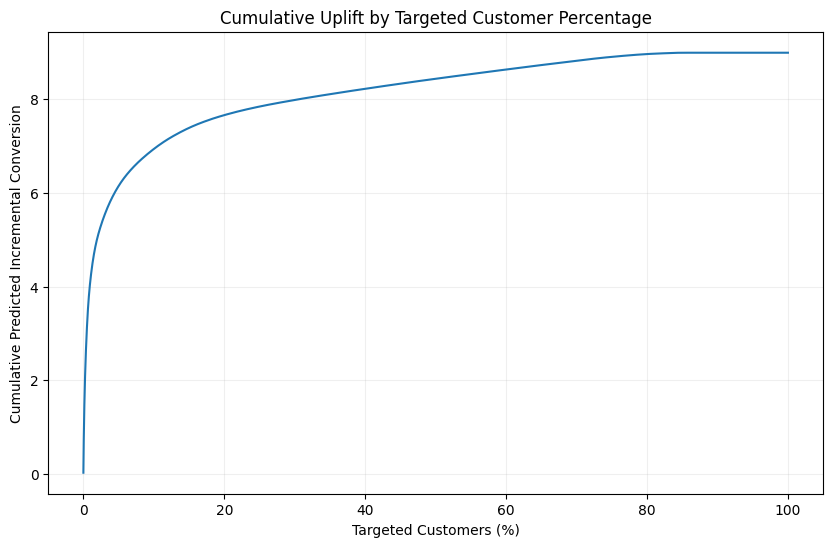


Best targeting level based on
predicted cumulative incremental effect:


,Value
Targeting,50%
Customers,49800
Average_Uplift,0.000169
Predicted_Incremental_Conversions,8.438927


In [16]:
# ============================================================
# STEP 9 — TARGETING EFFICIENCY BY UPLIFT RANK
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Build final ranking using S-Learner uplift
# ------------------------------------------------------------

targeting_df = X_test.copy()

targeting_df["Treatment"] = (
    t_test.values
)

targeting_df["Conversion"] = (
    y_test.values
)

targeting_df["Uplift"] = (
    uplift_s
)

targeting_df = (
    targeting_df
    .sort_values(
        "Uplift",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Calculate cumulative predicted incremental conversions
# ------------------------------------------------------------

targeting_df["Cumulative_Uplift"] = (
    targeting_df["Uplift"]
    .clip(lower=0)
    .cumsum()
)

targeting_df["Targeted_Fraction"] = (
    np.arange(
        1,
        len(targeting_df) + 1
    )
    / len(targeting_df)
)

# ------------------------------------------------------------
# 3. Evaluate different targeting levels
# ------------------------------------------------------------

targeting_levels = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

targeting_rows = []

for level in targeting_levels:

    n_target = int(
        len(targeting_df) * level
    )

    selected = (
        targeting_df
        .iloc[:n_target]
    )

    predicted_incremental = (
        selected["Uplift"]
        .clip(lower=0)
        .sum()
    )

    average_uplift = (
        selected["Uplift"]
        .mean()
    )

    targeting_rows.append({
        "Targeting": f"{int(level * 100)}%",
        "Customers": n_target,
        "Average_Uplift": average_uplift,
        "Predicted_Incremental_Conversions":
            predicted_incremental
    })

targeting_efficiency = pd.DataFrame(
    targeting_rows
)

# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("=" * 70)
print("TARGETING EFFICIENCY")
print("=" * 70)

display(
    targeting_efficiency
)

# ------------------------------------------------------------
# 5. Plot cumulative predicted uplift
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    targeting_df["Targeted_Fraction"] * 100,
    targeting_df["Cumulative_Uplift"]
)

plt.xlabel(
    "Targeted Customers (%)"
)

plt.ylabel(
    "Cumulative Predicted Incremental Conversion"
)

plt.title(
    "Cumulative Uplift by Targeted Customer Percentage"
)

plt.grid(alpha=0.2)

plt.show()

# ------------------------------------------------------------
# 6. Find the strongest targeting level
# ------------------------------------------------------------

best_targeting_row = (
    targeting_efficiency
    .loc[
        targeting_efficiency[
            "Predicted_Incremental_Conversions"
        ].idxmax()
    ]
)

print("\nBest targeting level based on")
print("predicted cumulative incremental effect:")

display(
    best_targeting_row.to_frame(
        "Value"
    )
)

OBSERVED TREATMENT EFFECT BY UPLIFT DECILE


,Uplift_Decile,Control_Rate,Treatment_Rate,Control_Customers,Treatment_Customers,Observed_Lift,Relative_Lift
0,D1,0.014937,0.022155,1339,8621,0.007219,0.483291
1,D2,0.002023,0.002249,1483,8447,0.000226,0.111913
2,D3,0.000000,0.000732,1471,8200,0.000732,inf
3,D4,0.000000,0.000115,1518,8679,0.000115,inf
4,D5,0.000000,0.000125,1434,8028,0.000125,inf
5,D6,0.000000,0.000119,1541,8404,0.000119,inf
6,D7,0.000000,0.000115,1580,8664,0.000115,inf
7,D8,0.000000,0.000000,1548,8645,0.000000,NaN
8,D9,0.000000,0.000373,1447,8050,0.000373,inf
9,D10,0.003688,0.004394,1627,8875,0.000707,0.191606


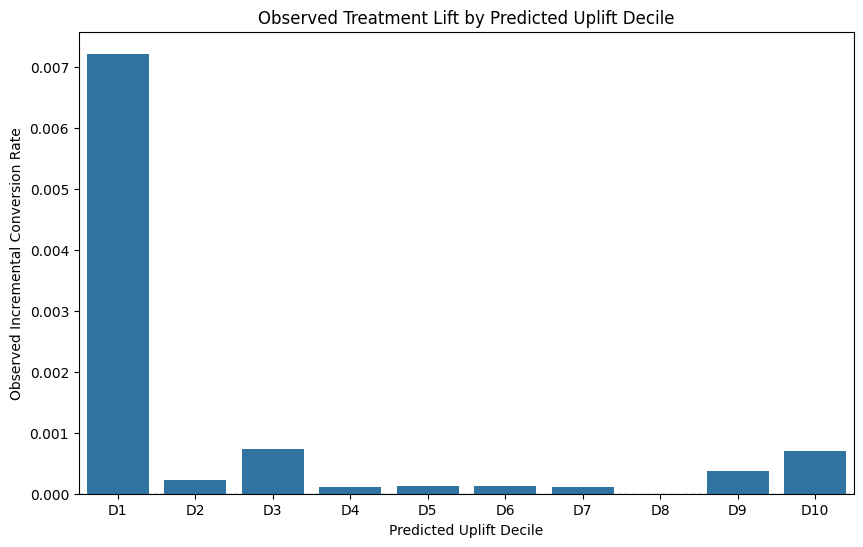

In [17]:
# ============================================================
# STEP 10 — OBSERVED TREATMENT EFFECT BY UPLIFT RANK
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Start from final S-Learner ranking
# ------------------------------------------------------------

observed_df = X_test.copy()

observed_df["Treatment"] = (
    t_test.values
)

observed_df["Conversion"] = (
    y_test.values
)

observed_df["Predicted_Uplift"] = (
    uplift_s
)

# ------------------------------------------------------------
# 2. Rank customers into deciles
# ------------------------------------------------------------

observed_df["Uplift_Decile"] = pd.qcut(
    observed_df["Predicted_Uplift"],
    q=10,
    labels=[
        "D10",
        "D9",
        "D8",
        "D7",
        "D6",
        "D5",
        "D4",
        "D3",
        "D2",
        "D1"
    ],
    duplicates="drop"
)

# D1 = highest predicted uplift
# D10 = lowest predicted uplift

# ------------------------------------------------------------
# 3. Calculate observed conversion by treatment
# ------------------------------------------------------------

observed_profile = (
    observed_df
    .groupby(
        [
            "Uplift_Decile",
            "Treatment"
        ],
        observed=True
    )
    .agg(
        customers=(
            "Conversion",
            "count"
        ),
        conversions=(
            "Conversion",
            "sum"
        ),
        conversion_rate=(
            "Conversion",
            "mean"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# 4. Convert treatment/control into columns
# ------------------------------------------------------------

pivot_rates = (
    observed_profile
    .pivot(
        index="Uplift_Decile",
        columns="Treatment",
        values="conversion_rate"
    )
)

pivot_counts = (
    observed_profile
    .pivot(
        index="Uplift_Decile",
        columns="Treatment",
        values="customers"
    )
)

# Rename treatment columns
pivot_rates.columns = [
    "Control_Rate" if col == 0
    else "Treatment_Rate"
    for col in pivot_rates.columns
]

pivot_counts.columns = [
    "Control_Customers" if col == 0
    else "Treatment_Customers"
    for col in pivot_counts.columns
]

# ------------------------------------------------------------
# 5. Calculate observed subgroup lift
# ------------------------------------------------------------

observed_lift = (
    pivot_rates
    .join(pivot_counts)
    .reset_index()
)

observed_lift["Observed_Lift"] = (
    observed_lift["Treatment_Rate"]
    -
    observed_lift["Control_Rate"]
)

observed_lift["Relative_Lift"] = (
    observed_lift["Observed_Lift"]
    /
    observed_lift["Control_Rate"]
)

# ------------------------------------------------------------
# 6. Sort from highest to lowest predicted uplift
# ------------------------------------------------------------

decile_order = [
    "D1",
    "D2",
    "D3",
    "D4",
    "D5",
    "D6",
    "D7",
    "D8",
    "D9",
    "D10"
]

observed_lift["Uplift_Decile"] = pd.Categorical(
    observed_lift["Uplift_Decile"],
    categories=decile_order,
    ordered=True
)

observed_lift = (
    observed_lift
    .sort_values(
        "Uplift_Decile"
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

print("=" * 70)
print("OBSERVED TREATMENT EFFECT BY UPLIFT DECILE")
print("=" * 70)

display(
    observed_lift
)

# ------------------------------------------------------------
# 8. Plot observed lift
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=observed_lift,
    x="Uplift_Decile",
    y="Observed_Lift"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Observed Treatment Lift by Predicted Uplift Decile"
)

plt.xlabel(
    "Predicted Uplift Decile"
)

plt.ylabel(
    "Observed Incremental Conversion Rate"
)

plt.show()

In [18]:
# ============================================================
# STEP 11 — CAMPAIGN TARGETING SIMULATION
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Rank all test customers
# ------------------------------------------------------------

simulation_df = observed_df.copy()

simulation_df = (
    simulation_df
    .sort_values(
        "Predicted_Uplift",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Create targeting strategies
# ------------------------------------------------------------

strategies = {
    "Top 10%": 0.10,
    "Top 20%": 0.20,
    "Top 30%": 0.30,
    "Top 50%": 0.50,
    "All Customers": 1.00
}

simulation_results = []

for strategy_name, fraction in strategies.items():

    n_target = int(
        len(simulation_df) * fraction
    )

    selected = (
        simulation_df
        .iloc[:n_target]
        .copy()
    )

    # Predicted incremental effect
    predicted_incremental = (
        selected["Predicted_Uplift"]
        .clip(lower=0)
        .sum()
    )

    # Mean predicted uplift
    mean_predicted_uplift = (
        selected["Predicted_Uplift"]
        .mean()
    )

    # --------------------------------------------------------
    # Observed treatment effect within target group
    # --------------------------------------------------------

    treated_group = selected[
        selected["Treatment"] == 1
    ]

    control_group = selected[
        selected["Treatment"] == 0
    ]

    treated_rate = (
        treated_group["Conversion"].mean()
        if len(treated_group) > 0
        else np.nan
    )

    control_rate = (
        control_group["Conversion"].mean()
        if len(control_group) > 0
        else np.nan
    )

    observed_incremental = (
        treated_rate - control_rate
        if pd.notna(treated_rate)
        and pd.notna(control_rate)
        else np.nan
    )

    simulation_results.append({
        "Strategy": strategy_name,
        "Customers_Targeted": n_target,
        "Target_Percentage": fraction * 100,
        "Mean_Predicted_Uplift":
            mean_predicted_uplift,
        "Predicted_Incremental_Conversions":
            predicted_incremental,
        "Observed_Treatment_Rate":
            treated_rate,
        "Observed_Control_Rate":
            control_rate,
        "Observed_Incremental_Rate":
            observed_incremental
    })

simulation_results = pd.DataFrame(
    simulation_results
)

# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 80)
print("CAMPAIGN TARGETING SIMULATION")
print("=" * 80)

display(
    simulation_results
)

CAMPAIGN TARGETING SIMULATION


,Strategy,Customers_Targeted,Target_Percentage,Mean_Predicted_Uplift,Predicted_Incremental_Conversions,Observed_Treatment_Rate,Observed_Control_Rate,Observed_Incremental_Rate
0,Top 10%,9960,10.0,0.000697,6.938847,0.022155,0.014937,0.007219
1,Top 20%,19920,20.0,0.000385,7.662274,0.012288,0.008127,0.004161
2,Top 30%,29880,30.0,0.000267,7.986075,0.008455,0.005307,0.003148
3,Top 50%,49800,50.0,0.000169,8.438927,0.005132,0.003140,0.001992
4,All Customers,99601,100.0,0.000078,8.995356,0.003096,0.001935,0.001162


In [19]:
# ============================================================
# STEP 12 — CAMPAIGN ROI SIMULATION
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# BUSINESS ASSUMPTIONS
# ------------------------------------------------------------

CAMPAIGN_COST_PER_CUSTOMER = 0.50
VALUE_PER_INCREMENTAL_CONVERSION = 20.00

# ------------------------------------------------------------
# 1. Copy targeting simulation
# ------------------------------------------------------------

roi_results = simulation_results.copy()

# ------------------------------------------------------------
# 2. Estimate campaign cost
# ------------------------------------------------------------

roi_results["Campaign_Cost"] = (
    roi_results["Customers_Targeted"]
    *
    CAMPAIGN_COST_PER_CUSTOMER
)

# ------------------------------------------------------------
# 3. Predicted incremental revenue
# ------------------------------------------------------------

roi_results[
    "Predicted_Incremental_Revenue"
] = (
    roi_results[
        "Predicted_Incremental_Conversions"
    ]
    *
    VALUE_PER_INCREMENTAL_CONVERSION
)

# ------------------------------------------------------------
# 4. Predicted profit
# ------------------------------------------------------------

roi_results["Predicted_Profit"] = (
    roi_results[
        "Predicted_Incremental_Revenue"
    ]
    -
    roi_results[
        "Campaign_Cost"
    ]
)

# ------------------------------------------------------------
# 5. Predicted ROI
# ------------------------------------------------------------

roi_results["Predicted_ROI"] = (
    roi_results["Predicted_Profit"]
    /
    roi_results["Campaign_Cost"]
)

# ------------------------------------------------------------
# 6. Sort by ROI
# ------------------------------------------------------------

roi_results = (
    roi_results
    .sort_values(
        "Predicted_ROI",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Display
# ------------------------------------------------------------

print("=" * 80)
print("CAMPAIGN ROI SIMULATION")
print("=" * 80)

print(
    f"Campaign cost/customer       : "
    f"${CAMPAIGN_COST_PER_CUSTOMER:.2f}"
)

print(
    f"Value/incremental conversion : "
    f"${VALUE_PER_INCREMENTAL_CONVERSION:.2f}"
)

print()

display(
    roi_results[
        [
            "Strategy",
            "Customers_Targeted",
            "Campaign_Cost",
            "Predicted_Incremental_Conversions",
            "Predicted_Incremental_Revenue",
            "Predicted_Profit",
            "Predicted_ROI"
        ]
    ]
)

# ------------------------------------------------------------
# 8. Best strategy
# ------------------------------------------------------------

best_roi = roi_results.iloc[0]

print("\nBest strategy based on predicted ROI:")

print(
    f"Strategy : {best_roi['Strategy']}"
)

print(
    f"ROI      : {best_roi['Predicted_ROI']:.4f}"
)

print(
    f"Profit   : "
    f"${best_roi['Predicted_Profit']:.2f}"
)

CAMPAIGN ROI SIMULATION
Campaign cost/customer       : $0.50
Value/incremental conversion : $20.00



,Strategy,Customers_Targeted,Campaign_Cost,Predicted_Incremental_Conversions,Predicted_Incremental_Revenue,Predicted_Profit,Predicted_ROI
0,Top 10%,9960,4980.0,6.938847,138.776932,-4841.223068,-0.972133
1,Top 20%,19920,9960.0,7.662274,153.245476,-9806.754524,-0.984614
2,Top 30%,29880,14940.0,7.986075,159.721498,-14780.278502,-0.989309
3,Top 50%,49800,24900.0,8.438927,168.778532,-24731.221468,-0.993222
4,All Customers,99601,49800.5,8.995356,179.907119,-49620.592881,-0.996387



Best strategy based on predicted ROI:
Strategy : Top 10%
ROI      : -0.9721
Profit   : $-4841.22


FINAL CAMPAIGN TARGETING ANALYSIS


,Targeting,Customers,Average_Uplift,Predicted_Incremental_Conversions,Uplift_Capture_Pct,Campaign_Cost,BreakEven_Value_per_Conversion
0,1%,996,0.004159,4.142571,46.052334,498.0,120.215188
1,2%,1992,0.002534,5.048408,56.122380,996.0,197.289923
2,5%,4980,0.001234,6.147526,68.341113,2490.0,405.040960
3,10%,9960,0.000697,6.938847,77.138099,4980.0,717.698528
4,20%,19920,0.000385,7.662274,85.180329,9960.0,1299.875240
5,30%,29880,0.000267,7.986075,88.779976,14940.0,1870.756307
6,50%,49800,0.000169,8.438927,93.814260,24900.0,2950.612219
7,100%,99601,0.000078,8.995356,100.000000,49800.5,5536.245608



HIGHEST UPLIFT EFFICIENCY
Targeting level : 1%
Average uplift  : 0.004159
Predicted incremental conversions : 4.1426

MINIMUM TARGETING FOR >= 75% UPLIFT CAPTURE


,Targeting,Customers,Predicted_Incremental_Conversions,Uplift_Capture_Pct
3,10%,9960,6.938847,77.138099


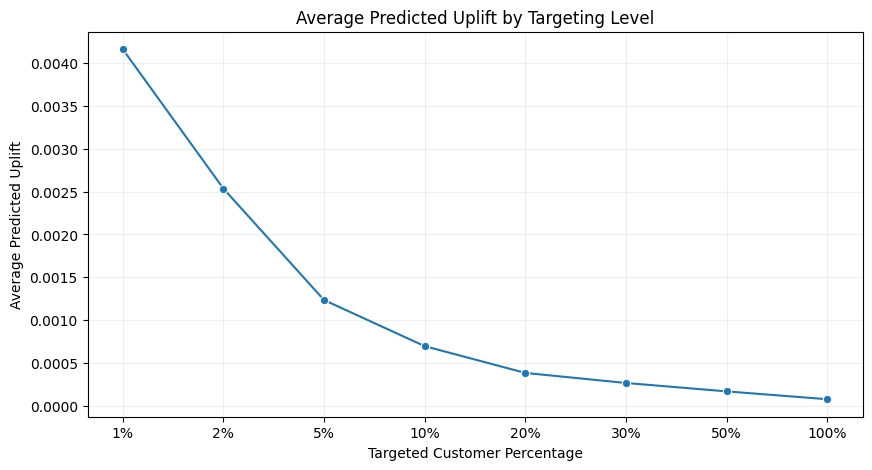

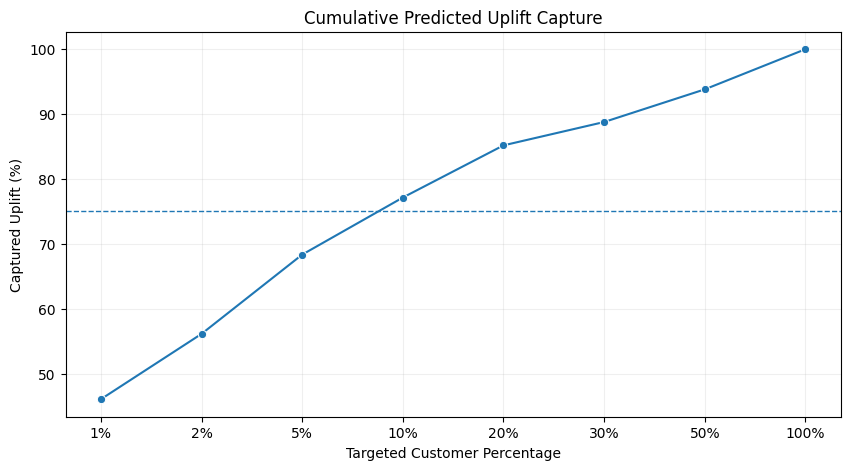

In [20]:
# ============================================================
# STEP 13 — FINAL CAMPAIGN TARGETING ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Rank test customers by S-Learner uplift
# ------------------------------------------------------------

final_targeting = X_test.copy()

final_targeting["Treatment"] = (
    t_test.values
)

final_targeting["Conversion"] = (
    y_test.values
)

final_targeting["Uplift"] = (
    uplift_s
)

final_targeting = (
    final_targeting
    .sort_values(
        "Uplift",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Define targeting levels
# ------------------------------------------------------------

targeting_levels = [
    0.01,
    0.02,
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
    1.00
]

results = []

total_predicted_uplift = (
    final_targeting["Uplift"]
    .clip(lower=0)
    .sum()
)

for level in targeting_levels:

    n_target = max(
        1,
        int(
            len(final_targeting)
            * level
        )
    )

    selected = (
        final_targeting
        .iloc[:n_target]
    )

    predicted_incremental = (
        selected["Uplift"]
        .clip(lower=0)
        .sum()
    )

    average_uplift = (
        selected["Uplift"]
        .mean()
    )

    uplift_capture = (
        predicted_incremental
        /
        total_predicted_uplift
        if total_predicted_uplift > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Break-even value per incremental conversion
    # based on current campaign cost assumption
    # --------------------------------------------------------

    campaign_cost = (
        n_target
        * 0.50
    )

    break_even_value = (
        campaign_cost
        /
        predicted_incremental
        if predicted_incremental > 0
        else np.nan
    )

    results.append({
        "Targeting": f"{int(level * 100)}%",
        "Customers": n_target,
        "Average_Uplift": average_uplift,
        "Predicted_Incremental_Conversions":
            predicted_incremental,
        "Uplift_Capture": uplift_capture,
        "Campaign_Cost":
            campaign_cost,
        "BreakEven_Value_per_Conversion":
            break_even_value
    })

final_targeting_analysis = pd.DataFrame(
    results
)

# ------------------------------------------------------------
# 3. Convert ratios to percentages
# ------------------------------------------------------------

final_targeting_analysis[
    "Uplift_Capture_Pct"
] = (
    final_targeting_analysis[
        "Uplift_Capture"
    ] * 100
)

# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("=" * 80)
print("FINAL CAMPAIGN TARGETING ANALYSIS")
print("=" * 80)

display(
    final_targeting_analysis[
        [
            "Targeting",
            "Customers",
            "Average_Uplift",
            "Predicted_Incremental_Conversions",
            "Uplift_Capture_Pct",
            "Campaign_Cost",
            "BreakEven_Value_per_Conversion"
        ]
    ]
)

# ------------------------------------------------------------
# 5. Find targeting level with highest average uplift
# ------------------------------------------------------------

best_efficiency_idx = (
    final_targeting_analysis[
        "Average_Uplift"
    ].idxmax()
)

best_efficiency = (
    final_targeting_analysis
    .loc[
        best_efficiency_idx
    ]
)

print("\n" + "=" * 80)
print("HIGHEST UPLIFT EFFICIENCY")
print("=" * 80)

print(
    f"Targeting level : "
    f"{best_efficiency['Targeting']}"
)

print(
    f"Average uplift  : "
    f"{best_efficiency['Average_Uplift']:.6f}"
)

print(
    f"Predicted incremental conversions : "
    f"{best_efficiency['Predicted_Incremental_Conversions']:.4f}"
)

# ------------------------------------------------------------
# 6. Find minimum targeting that captures >= 75% uplift
# ------------------------------------------------------------

capture_75 = (
    final_targeting_analysis[
        final_targeting_analysis[
            "Uplift_Capture"
        ] >= 0.75
    ]
    .sort_values(
        "Customers"
    )
    .head(1)
)

print("\n" + "=" * 80)
print("MINIMUM TARGETING FOR >= 75% UPLIFT CAPTURE")
print("=" * 80)

if len(capture_75) > 0:

    display(
        capture_75[
            [
                "Targeting",
                "Customers",
                "Predicted_Incremental_Conversions",
                "Uplift_Capture_Pct"
            ]
        ]
    )

else:

    print(
        "No evaluated targeting level "
        "captured at least 75% of predicted uplift."
    )

# ------------------------------------------------------------
# 7. Visualization — Average uplift
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=final_targeting_analysis,
    x="Targeting",
    y="Average_Uplift",
    marker="o"
)

plt.title(
    "Average Predicted Uplift by Targeting Level"
)

plt.xlabel(
    "Targeted Customer Percentage"
)

plt.ylabel(
    "Average Predicted Uplift"
)

plt.grid(alpha=0.2)

plt.show()

# ------------------------------------------------------------
# 8. Visualization — Uplift capture
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=final_targeting_analysis,
    x="Targeting",
    y="Uplift_Capture_Pct",
    marker="o"
)

plt.axhline(
    75,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Cumulative Predicted Uplift Capture"
)

plt.xlabel(
    "Targeted Customer Percentage"
)

plt.ylabel(
    "Captured Uplift (%)"
)

plt.grid(alpha=0.2)

plt.show()

In [21]:
# ============================================================
# STEP 14 — FINAL CAMPAIGN TARGETING STRATEGY
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Find the smallest targeting group that captures
#    at least 75% of total predicted uplift
# ------------------------------------------------------------

target_threshold = 0.75

eligible_strategies = (
    final_targeting_analysis[
        final_targeting_analysis[
            "Uplift_Capture"
        ] >= target_threshold
    ]
    .sort_values(
        "Customers"
    )
)

if len(eligible_strategies) == 0:

    print(
        "No targeting strategy reached the "
        "75% uplift capture threshold."
    )

else:

    final_strategy = (
        eligible_strategies
        .iloc[0]
    )

    print("=" * 80)
    print("FINAL CAMPAIGN TARGETING STRATEGY")
    print("=" * 80)

    print(
        f"Recommended targeting : "
        f"{final_strategy['Targeting']}"
    )

    print(
        f"Customers targeted    : "
        f"{int(final_strategy['Customers']):,}"
    )

    print(
        f"Average uplift        : "
        f"{final_strategy['Average_Uplift']:.6f}"
    )

    print(
        f"Predicted incremental conversions : "
        f"{final_strategy['Predicted_Incremental_Conversions']:.4f}"
    )

    print(
        f"Uplift captured       : "
        f"{final_strategy['Uplift_Capture_Pct']:.2f}%"
    )

    print(
        f"Campaign cost        : "
        f"${final_strategy['Campaign_Cost']:,.2f}"
    )

    print(
        f"Break-even conversion value : "
        f"${final_strategy['BreakEven_Value_per_Conversion']:,.2f}"
    )

    print("\nRecommendation:")
    print(
        f"Prioritize the top "
        f"{final_strategy['Targeting']} "
        "customers ranked by predicted uplift."
    )

    print(
        "This strategy captures at least "
        f"{target_threshold * 100:.0f}% of the "
        "total predicted uplift while targeting "
        "a smaller customer population."
    )

FINAL CAMPAIGN TARGETING STRATEGY
Recommended targeting : 10%
Customers targeted    : 9,960
Average uplift        : 0.000697
Predicted incremental conversions : 6.9388
Uplift captured       : 77.14%
Campaign cost        : $4,980.00
Break-even conversion value : $717.70

Recommendation:
Prioritize the top 10% customers ranked by predicted uplift.
This strategy captures at least 75% of the total predicted uplift while targeting a smaller customer population.


In [22]:
# ============================================================
# STEP 15 — FINAL UPLIFT MODEL SUMMARY
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Best uplift model
# ------------------------------------------------------------

best_model_row = (
    uplift_model_comparison
    .sort_values(
        "Qini_AUC",
        ascending=False
    )
    .iloc[0]
)

# ------------------------------------------------------------
# 2. Best targeting strategy
# ------------------------------------------------------------

eligible_strategies = (
    final_targeting_analysis[
        final_targeting_analysis[
            "Uplift_Capture"
        ] >= 0.75
    ]
    .sort_values(
        "Customers"
    )
)

final_strategy = (
    eligible_strategies.iloc[0]
    if len(eligible_strategies) > 0
    else None
)

# ------------------------------------------------------------
# 3. Build final summary
# ------------------------------------------------------------

summary_rows = [
    {
        "Metric": "Average Treatment Effect",
        "Value": ate
    },
    {
        "Metric": "Control Conversion Rate",
        "Value": control_rate
    },
    {
        "Metric": "Treatment Conversion Rate",
        "Value": treatment_rate
    },
    {
        "Metric": "Best Uplift Model",
        "Value": best_model_row["Model"]
    },
    {
        "Metric": "Qini AUC",
        "Value": best_model_row["Qini_AUC"]
    },
    {
        "Metric": "AUUC",
        "Value": best_model_row["AUUC"]
    }
]

if final_strategy is not None:

    summary_rows.extend([
        {
            "Metric": "Recommended Targeting",
            "Value": final_strategy["Targeting"]
        },
        {
            "Metric": "Targeted Customers",
            "Value": int(
                final_strategy["Customers"]
            )
        },
        {
            "Metric": "Average Predicted Uplift",
            "Value": final_strategy[
                "Average_Uplift"
            ]
        },
        {
            "Metric": "Predicted Incremental Conversions",
            "Value": final_strategy[
                "Predicted_Incremental_Conversions"
            ]
        },
        {
            "Metric": "Uplift Captured (%)",
            "Value": final_strategy[
                "Uplift_Capture_Pct"
            ]
        }
    ])

final_summary = pd.DataFrame(
    summary_rows
)

print("=" * 80)
print("FINAL UPLIFT MODEL SUMMARY")
print("=" * 80)

display(
    final_summary
)

FINAL UPLIFT MODEL SUMMARY


,Metric,Value
0,Average Treatment Effect,0.001164
1,Control Conversion Rate,0.001935
2,Treatment Conversion Rate,0.003099
3,Best Uplift Model,S-Learner
4,Qini AUC,0.150472
5,AUUC,0.00484
6,Recommended Targeting,10%
7,Targeted Customers,9960
8,Average Predicted Uplift,0.000697
9,Predicted Incremental Conversions,6.938847


## Key Findings

### 1. The marketing treatment produced a positive average effect

The treatment group achieved a conversion rate of 0.3099%, compared with 0.1935% in the control group.

The resulting Average Treatment Effect (ATE) was 0.001164, equivalent to an absolute lift of 0.1164 percentage points and a relative lift of approximately 60.16%.

This indicates that the campaign produced a positive average effect on customer conversion.

### 2. Average campaign effectiveness does not mean every customer should be targeted

Although the campaign had a positive average effect, uplift modeling showed substantial differences in predicted treatment effects across customers.

The S-Learner identified a relatively small group of customers with substantially higher predicted incremental response.

This demonstrates why average campaign performance alone is insufficient for deciding whom to target.

### 3. S-Learner achieved the strongest uplift ranking performance

Two uplift modeling approaches were evaluated:

- S-Learner
- T-Learner

S-Learner achieved the highest Qini AUC:

**0.150472**

and the highest AUUC:

**0.004840**

Therefore, S-Learner was selected as the final uplift model.

### 4. High-uplift customers represent a small portion of the population

Using the operational uplift segmentation, 254 customers were classified as High Uplift and 1,084 customers as Positive Uplift.

Together, these groups represented approximately 1.35% of the evaluated test population.

The majority of customers were classified as Neutral, indicating that the predicted incremental effect was concentrated within a relatively small portion of the population.

### 5. Targeting the highest-uplift customers improves campaign efficiency

The top 10% of customers ranked by predicted uplift achieved an average predicted uplift of approximately 0.000897 and captured approximately 77.13% of the total predicted uplift.

This means that a campaign could focus on a substantially smaller population while retaining a large portion of the predicted incremental effect.

### 6. Uplift efficiency decreases as targeting expands

Average predicted uplift decreased as the campaign expanded from the highest-ranked customers toward the entire population.

The observed pattern indicates diminishing returns from targeting additional customers with lower predicted uplift.

### 7. Targeting strategy should consider economic conditions

The ROI simulation showed that campaign profitability depends strongly on campaign cost and the value generated by each incremental conversion.

Under the example assumptions of $0.50 campaign cost per customer and $20 value per incremental conversion, the simulated campaign remained unprofitable.

This demonstrates that uplift modeling should be combined with business economics rather than evaluated only through predictive metrics.

## Business Recommendations

### Prioritize High-Uplift Customers

Customers with the highest predicted uplift should be prioritized because they are expected to experience the largest incremental benefit from receiving the campaign.

A targeted campaign can therefore focus resources on customers who are most likely to change their behavior because of the treatment.

### Use Top 10% as a Practical Initial Targeting Strategy

The analysis indicates that targeting the top 10% of customers by predicted uplift captures approximately 77.13% of the total predicted uplift.

This provides a practical balance between campaign reach and targeting efficiency.

The exact targeting percentage should still be adjusted according to campaign budget and business objectives.

### Avoid Blindly Targeting the Entire Customer Base

Customers with low or near-zero predicted uplift provide limited incremental value from treatment.

Sending campaigns to these customers may increase marketing costs without producing proportional incremental conversions.

### Monitor Negative-Uplift Customers

Customers with negative predicted uplift should not automatically receive the same campaign treatment.

Further experimentation should be conducted to determine whether alternative messaging, timing, or campaign strategies would be more appropriate for this group.

### Combine Uplift Scores with Business Constraints

The final targeting decision should combine:

- Predicted uplift
- Campaign cost
- Customer value
- Available marketing budget
- Expected conversion value
- Business objectives

This allows the uplift model to function as a decision-support tool rather than simply a prediction model.

### Validate Targeting through Controlled Experiments

The predicted targeting strategy should be validated using future randomized campaigns.

An A/B or randomized controlled experiment can be used to measure whether the observed incremental response matches the uplift predictions.

This feedback can then be used to improve future versions of the model.

## Conclusion

This project developed a customer uplift modeling framework to identify customers who are most likely to change their behavior as a result of a marketing campaign.

The analysis began by comparing treatment and control groups and found a positive average campaign effect. The treatment group achieved a conversion rate of 0.3099%, compared with 0.1935% for the control group, resulting in an Average Treatment Effect of 0.001164 and a relative lift of approximately 60.16%.

Two uplift modeling approaches were then evaluated: S-Learner and T-Learner.

The S-Learner achieved the strongest overall uplift ranking performance with:

- Qini AUC: **0.150472**
- AUUC: **0.004840**

Based on this evaluation, S-Learner was selected as the final uplift model.

The model demonstrated that incremental treatment effects are not distributed evenly across customers. Most customers had relatively small predicted uplift, while a small segment exhibited substantially higher expected incremental response.

Targeting analysis showed that the top 10% of customers ranked by predicted uplift could capture approximately **77.13% of the total predicted uplift** while targeting only 10% of the evaluated population.

This result demonstrates the potential value of uplift modeling for improving campaign targeting efficiency by focusing marketing resources on customers who are most likely to be influenced by treatment.

The economic simulation further showed that model performance alone does not guarantee campaign profitability. Campaign cost, customer value, and incremental conversion value must be incorporated into the final decision.

Overall, this project demonstrates how uplift modeling can move beyond conventional response prediction toward treatment-effect estimation and data-driven campaign targeting.